# Wizualizacja wyników treningu Faster R-CNN
Ten notebook wczytuje najnowszy plik `metrics.csv` wygenerowany przez PyTorch Lightning i rysuje piękne wykresy dla poszczególnych składowych funkcji straty (loss). Dzięki temu możemy zobaczyć, jak model się uczył.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawiamy estetyczny styl z biblioteki seaborn
sns.set_theme(style="darkgrid", context="notebook", palette="muted")

# Wyszukaliśmy w Twoim środowisku, że najnowszy run to version_6
log_path = "../lightning_logs/version_7/metrics.csv"

# Wczytujemy plik do obiektu pandas DataFrame
df = pd.read_csv(log_path)

print("Logi wczytane pomyślnie!")
print("Dostępne kolumny:", df.columns.tolist())


Logi wczytane pomyślnie!
Dostępne kolumny: ['epoch', 'step', 'train/loss', 'train/loss_box_reg', 'train/loss_classifier', 'train/loss_objectness', 'train/loss_rpn_box_reg']


### Analiza funkcji straty (Loss)
PyTorch Lightning zapisuje dane z każdego logowanego kroku. Ze względu na asynchroniczność zapisu, niektóre wiersze mogą mieć wartości `NaN`. Najlepiej jest zgrupować te dane po numerze kroku (`step`).

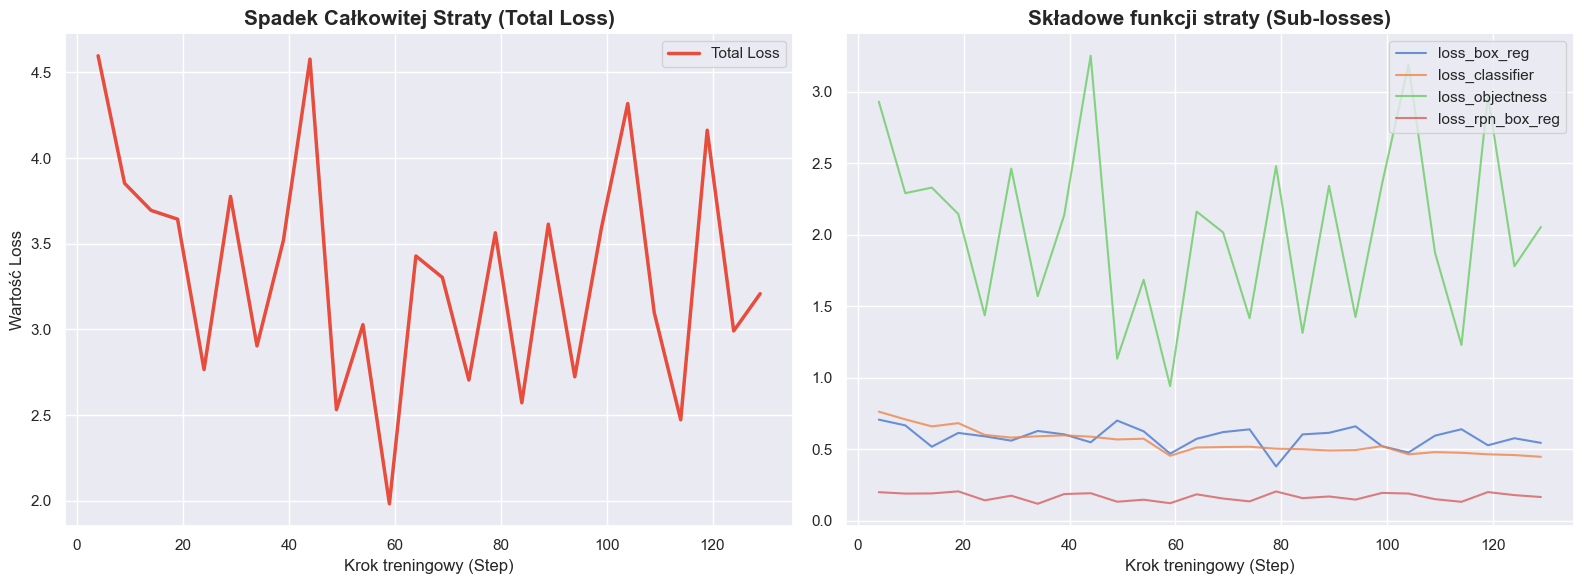

In [5]:
# Filtrujemy wszystkie kolumny, w których nazwie występuje słowo 'loss'
loss_cols = [col for col in df.columns if 'loss' in col]

# Grupujemy po 'step' wyciągając średnią dla danego kroku
df_grouped = df.groupby('step')[loss_cols].mean()

# Tworzymy duże, czytelne okno na dwa wykresy (1 wiersz, 2 kolumny)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# WYKRES 1: CAŁKOWITY LOSS (Total Loss)
if 'train/loss' in df_grouped.columns:
    # Funkcja usuwa puste wartości, żeby wykres był ciągły
    total_loss = df_grouped['train/loss'].dropna()
    axes[0].plot(total_loss.index, total_loss.values, color='#e74c3c', linewidth=2.5, label='Total Loss')
    axes[0].set_title('Spadek Całkowitej Straty (Total Loss)', fontsize=15, fontweight='bold')
    axes[0].set_xlabel('Krok treningowy (Step)', fontsize=12)
    axes[0].set_ylabel('Wartość Loss', fontsize=12)
    axes[0].legend()

# WYKRES 2: SKŁADOWE LOSSU (np. błąd klasyfikacji, błąd precyzji boxów)
for col in loss_cols:
    if col != 'train/loss':
        series = df_grouped[col].dropna()
        if not series.empty:
            axes[1].plot(series.index, series.values, linewidth=1.5, alpha=0.8, label=col.replace('train/', ''))

axes[1].set_title('Składowe funkcji straty (Sub-losses)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Krok treningowy (Step)', fontsize=12)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


### Analiza funkcji straty według epoki (Loss per Epoch)
Grupując dane po epokach widzimy szerszy, gładszy obraz całego procesu trenowania. Pojedyncze wahania w krokach znikają, a w zamian dostajemy globalny trend uczenia się modelu.

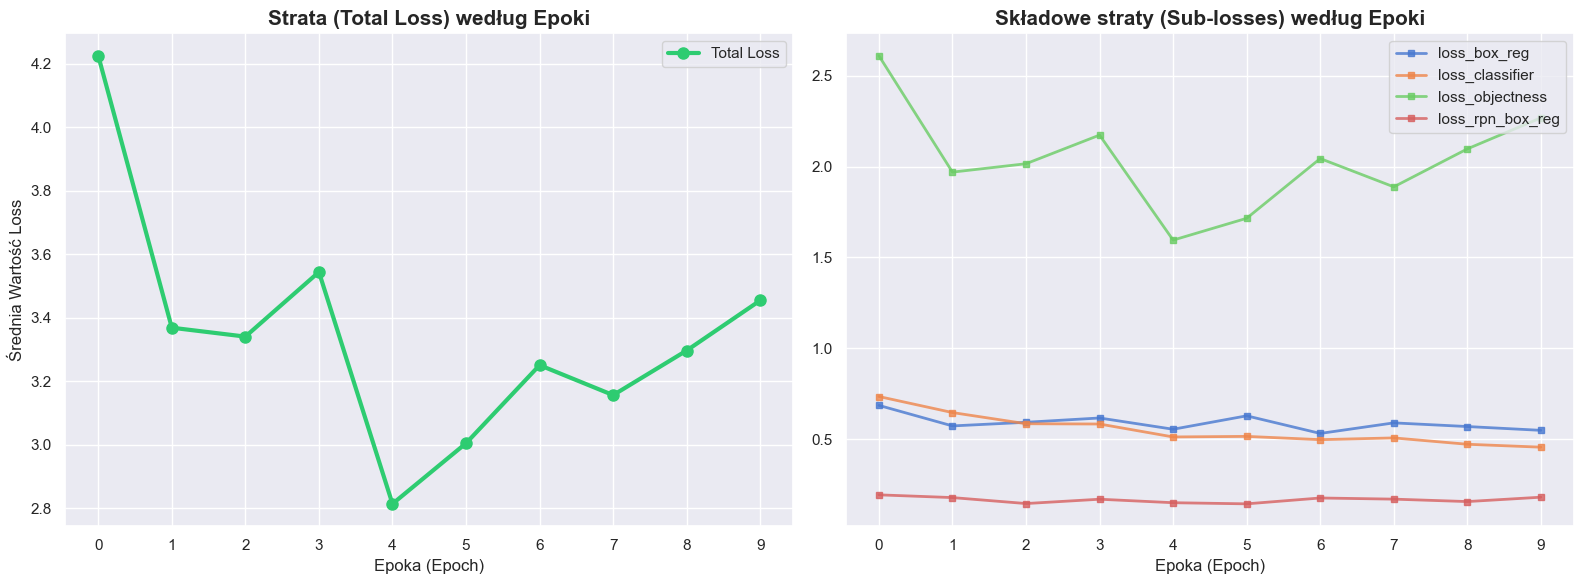

In [6]:
# Grupujemy po kolumnie 'epoch', wyciągając średnią dla danej epoki
df_epoch_grouped = df.groupby('epoch')[loss_cols].mean()

# Upewniamy się, że nie liczymy wierszy, gdzie epoka wynosi NaN
df_epoch_grouped = df_epoch_grouped.dropna(how='all')

# Tworzymy wykresy uśrednione po epokach
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# WYKRES 1: CAŁKOWITY LOSS WEDŁUG EPOKI
if 'train/loss' in df_epoch_grouped.columns:
    total_loss_epoch = df_epoch_grouped['train/loss'].dropna()
    axes[0].plot(total_loss_epoch.index, total_loss_epoch.values, color='#2ecc71', linewidth=3, marker='o', markersize=8, label='Total Loss')
    axes[0].set_title('Strata (Total Loss) według Epoki', fontsize=15, fontweight='bold')
    axes[0].set_xlabel('Epoka (Epoch)', fontsize=12)
    axes[0].set_ylabel('Średnia Wartość Loss', fontsize=12)
    if not total_loss_epoch.empty:
        axes[0].set_xticks(range(int(total_loss_epoch.index.max()) + 1))
    axes[0].legend()

# WYKRES 2: SKŁADOWE LOSSU WEDŁUG EPOKI
for col in loss_cols:
    if col != 'train/loss':
        series = df_epoch_grouped[col].dropna()
        if not series.empty:
            axes[1].plot(series.index, series.values, linewidth=2, marker='s', markersize=5, alpha=0.8, label=col.replace('train/', ''))

axes[1].set_title('Składowe straty (Sub-losses) według Epoki', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Epoka (Epoch)', fontsize=12)
if not df_epoch_grouped.empty:
    axes[1].set_xticks(range(int(df_epoch_grouped.index.max()) + 1))
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()
